<a href="https://colab.research.google.com/github/rfpmaa/uas-ml/blob/main/notebook/UAS_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

In [51]:
!pip install xgboost

In [6]:
url = "https://raw.githubusercontent.com/rfpmaa/uas-ml/main/dataset/beasiswa.csv"

df = pd.read_csv(url)

df.head()

,IPK,Semester,Penghasilan_Ortu,Tanggungan_Keluarga,Prestasi,Aktif_Organisasi,Status_Rumah,Jenis_Kelamin,Diterima_Beasiswa
0,3.37,2,2000000,3,Internasional,Tidak,Milik Sendiri,P,0
1,3.15,5,4000000,6,Tidak Ada,Ya,Kos/Asrama,P,1
2,3.43,3,1500000,6,Provinsi,Ya,Kontrak,P,1
3,3.73,6,1000000,5,Tidak Ada,Tidak,Milik Sendiri,L,1
4,3.12,2,500000,1,Tidak Ada,Tidak,Milik Sendiri,P,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   IPK                  300 non-null    float64
 1   Semester             300 non-null    int64  
 2   Penghasilan_Ortu     300 non-null    int64  
 3   Tanggungan_Keluarga  300 non-null    int64  
 4   Prestasi             300 non-null    object 
 5   Aktif_Organisasi     300 non-null    object 
 6   Status_Rumah         300 non-null    object 
 7   Jenis_Kelamin        300 non-null    object 
 8   Diterima_Beasiswa    300 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 21.2+ KB


In [8]:
df.describe()

,IPK,Semester,Penghasilan_Ortu,Tanggungan_Keluarga,Diterima_Beasiswa
count,300.000000,300.000000,3.000000e+02,300.000000,300.000000
mean,3.195400,4.906667,2.065000e+06,3.396667,0.706667
std,0.336704,1.999487,1.283393e+06,1.701658,0.456051
min,2.070000,2.000000,5.000000e+05,1.000000,0.000000
25%,2.960000,3.000000,1.000000e+06,2.000000,0.000000
50%,3.220000,5.000000,1.500000e+06,3.000000,1.000000
75%,3.420000,6.000000,3.000000e+06,5.000000,1.000000
max,4.000000,8.000000,6.000000e+06,6.000000,1.000000


In [9]:
print("Jumlah Baris dan Kolom :", df.shape)

Jumlah Baris dan Kolom : (300, 9)


In [10]:
df.dtypes

,0
IPK,float64
Semester,int64
Penghasilan_Ortu,int64
Tanggungan_Keluarga,int64
Prestasi,object
Aktif_Organisasi,object
Status_Rumah,object
Jenis_Kelamin,object
Diterima_Beasiswa,int64


In [11]:
# Cek missing values
df.isnull().sum()

,0
IPK,0
Semester,0
Penghasilan_Ortu,0
Tanggungan_Keluarga,0
Prestasi,0
Aktif_Organisasi,0
Status_Rumah,0
Jenis_Kelamin,0
Diterima_Beasiswa,0


In [12]:
# Cek data duplikat
df.duplicated().sum()

np.int64(0)

In [13]:
print("Kategori Prestasi")
print(df["Prestasi"].unique())

print("\nKategori Status Rumah")
print(df["Status_Rumah"].unique())

print("\nKategori Jenis Kelamin")
print(df["Jenis_Kelamin"].unique())

Kategori Prestasi
['Internasional' 'Tidak Ada' 'Provinsi' 'Kabupaten' 'Nasional']

Kategori Status Rumah
['Milik Sendiri' 'Kos/Asrama' 'Kontrak' 'Menumpang']

Kategori Jenis Kelamin
['P' 'L']


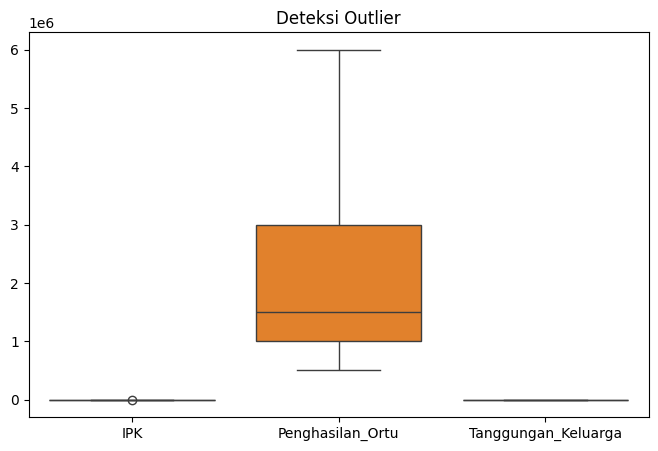

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[
        ["IPK",
         "Penghasilan_Ortu",
         "Tanggungan_Keluarga"]
    ]
)

plt.title("Deteksi Outlier")
plt.show()

In [15]:
df["Diterima_Beasiswa"].value_counts()

,count
Diterima_Beasiswa,
1,212
0,88


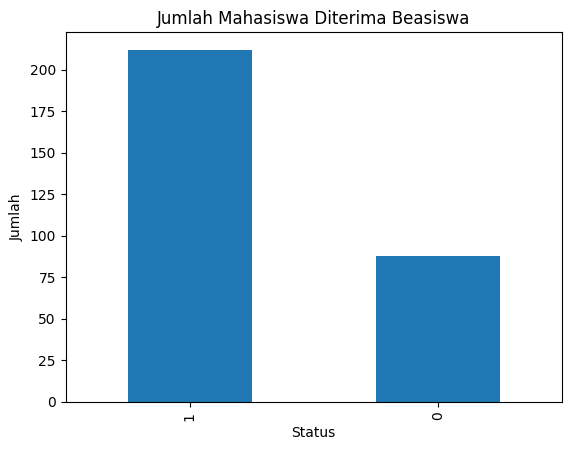

In [16]:
df["Diterima_Beasiswa"].value_counts().plot(kind="bar")

plt.title("Jumlah Mahasiswa Diterima Beasiswa")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.show()

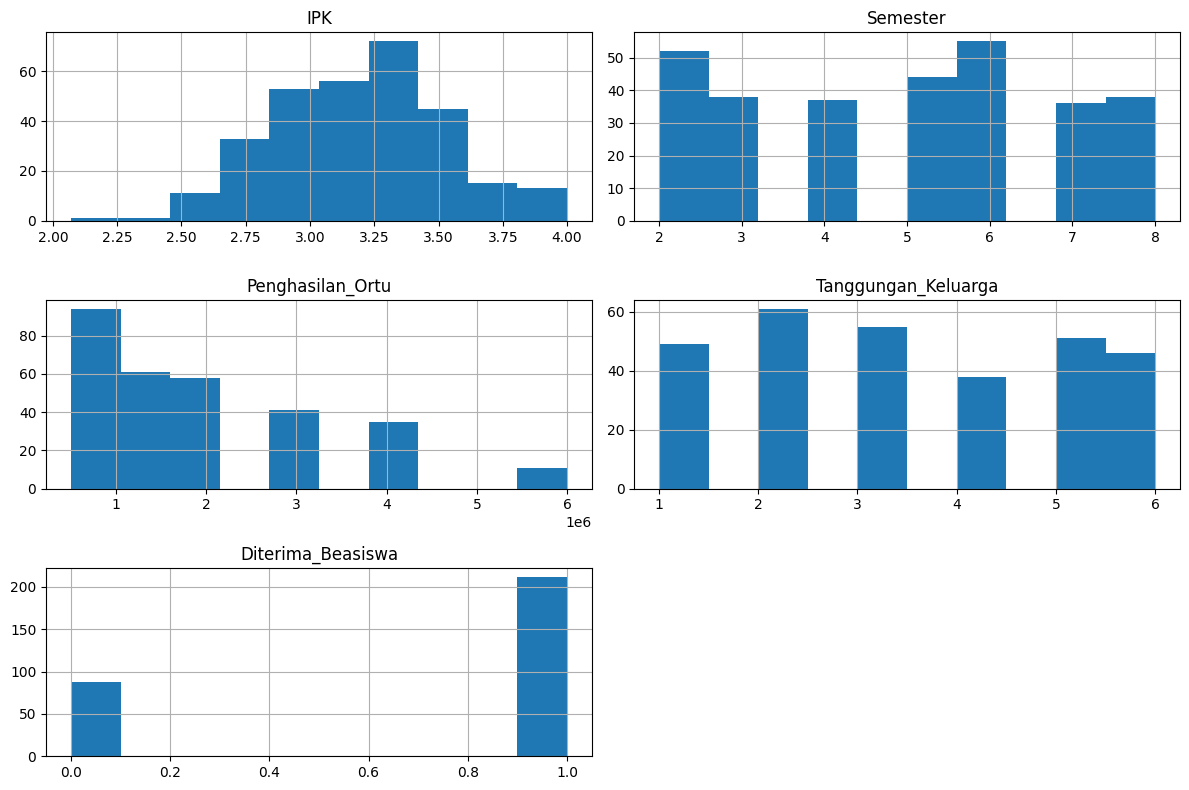

In [17]:
df.hist(figsize=(12,8))

plt.tight_layout()

plt.show()

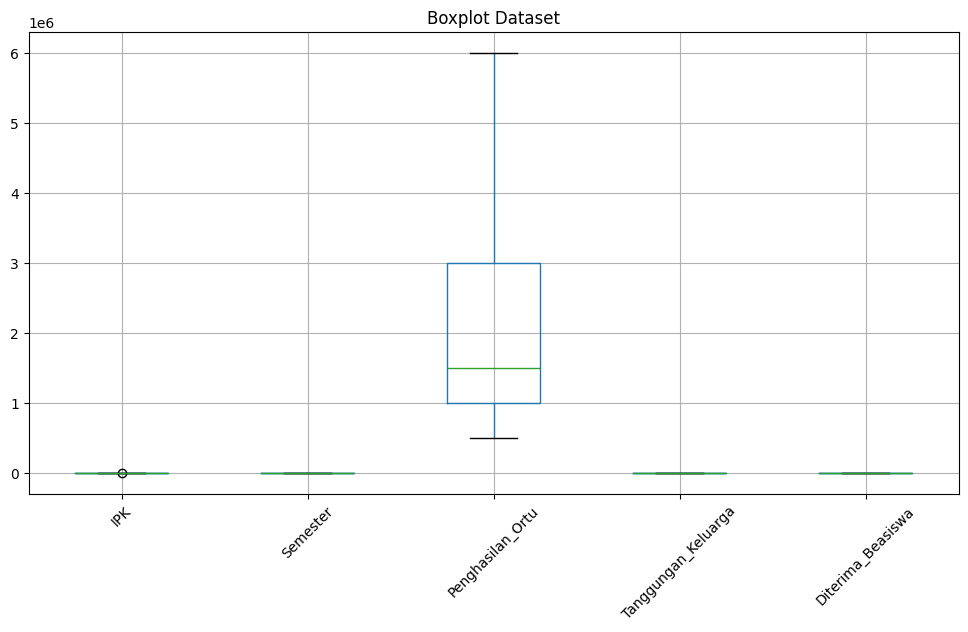

In [18]:
plt.figure(figsize=(12,6))

df.boxplot()

plt.xticks(rotation=45)

plt.title("Boxplot Dataset")

plt.show()

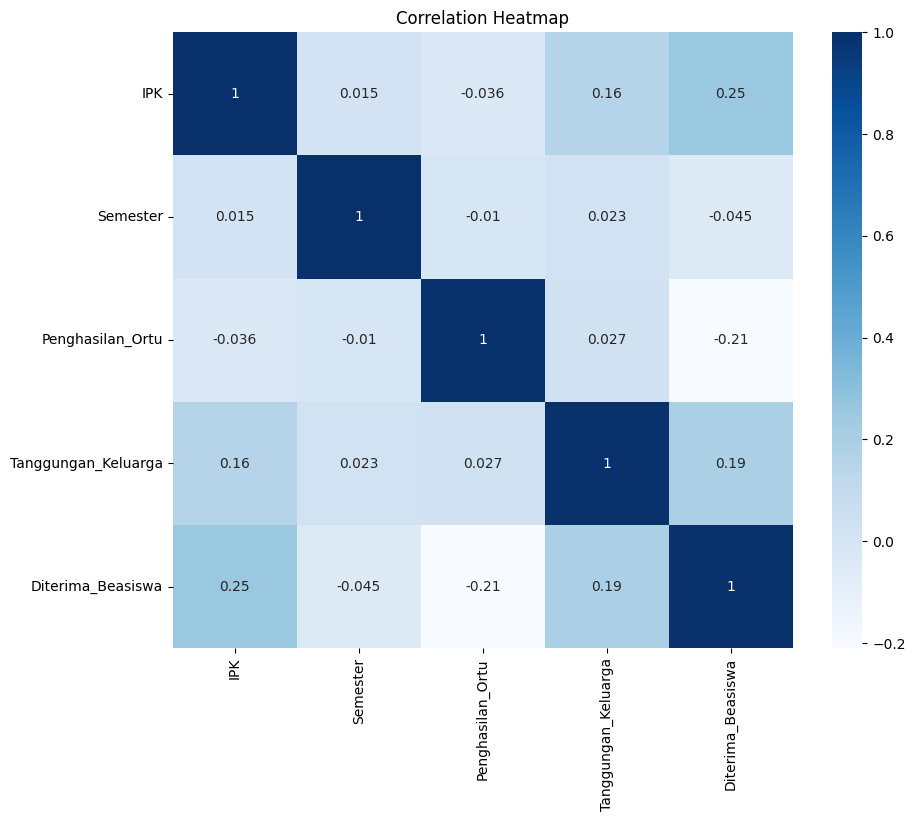

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

df_encode = df.copy()

le = LabelEncoder()

categorical_cols = [
    'Prestasi',
    'Aktif_Organisasi',
    'Status_Rumah',
    'Jenis_Kelamin',
    'Diterima_Beasiswa'
]

for col in categorical_cols:
    df_encode[col] = le.fit_transform(df_encode[col])

df_encode.head()

,IPK,Semester,Penghasilan_Ortu,Tanggungan_Keluarga,Prestasi,Aktif_Organisasi,Status_Rumah,Jenis_Kelamin,Diterima_Beasiswa
0,3.37,2,2000000,3,0,0,3,1,0
1,3.15,5,4000000,6,4,1,1,1,1
2,3.43,3,1500000,6,3,1,0,1,1
3,3.73,6,1000000,5,4,0,3,0,1
4,3.12,2,500000,1,4,0,3,1,1


In [21]:
from sklearn.preprocessing import StandardScaler

X = df_encode.drop("Diterima_Beasiswa", axis=1)
y = df_encode["Diterima_Beasiswa"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling berhasil")

Scaling berhasil


In [22]:
X = df_encode.drop("Diterima_Beasiswa", axis=1)
y = df_encode["Diterima_Beasiswa"]

print("Jumlah fitur :", X.shape)
print("Jumlah target :", y.shape)

Jumlah fitur : (300, 8)
Jumlah target : (300,)


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest berhasil dilatih!")

Random Forest berhasil dilatih!


In [25]:
y_pred_rf = rf.predict(X_test)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7333333333333333

Classification Report

              precision    recall  f1-score   support

           0       0.60      0.33      0.43        18
           1       0.76      0.90      0.83        42

    accuracy                           0.73        60
   macro avg       0.68      0.62      0.63        60
weighted avg       0.71      0.73      0.71        60



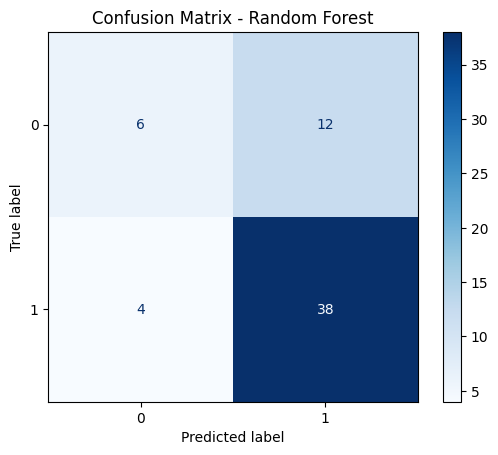

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")

plt.savefig(
    "confusion_matrix_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
plt.savefig("confusion_matrix_rf.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

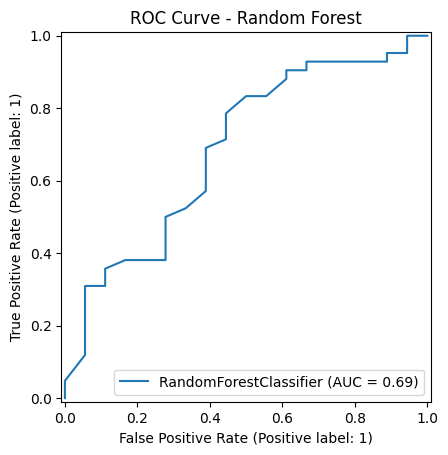

In [71]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")

plt.savefig(
    "roc_curve_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
plt.savefig("roc_curve_rf.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

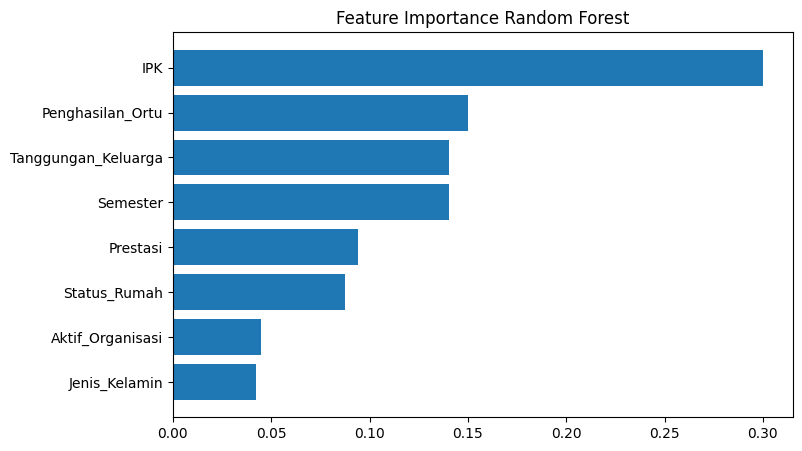

In [31]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance Random Forest")

plt.show()

In [65]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", accuracy_rf)

Accuracy Random Forest: 0.7333333333333333


In [49]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [32]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

print("SVM berhasil dilatih!")

SVM berhasil dilatih!


In [33]:
y_pred_svm = svm.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy SVM :", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_svm, zero_division=0))

Accuracy SVM : 0.7

Classification Report

              precision    recall  f1-score   support

           0       0.50      0.06      0.10        18
           1       0.71      0.98      0.82        42

    accuracy                           0.70        60
   macro avg       0.60      0.52      0.46        60
weighted avg       0.64      0.70      0.60        60



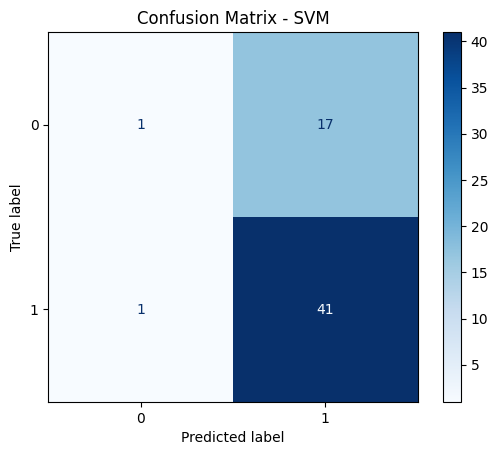

In [72]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - SVM")

plt.savefig("confusion_matrix_svm.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
plt.savefig("confusion_matrix_svm.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

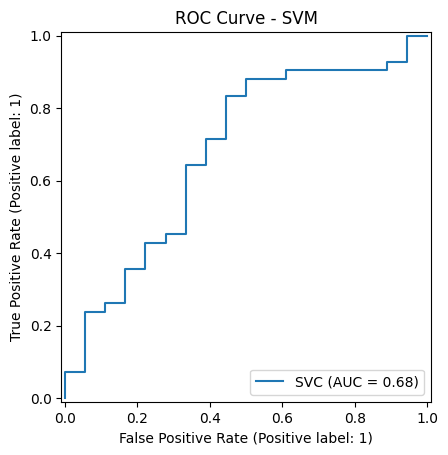

In [73]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    svm,
    X_test,
    y_test
)

plt.title("ROC Curve - SVM")

plt.savefig("roc_curve_svm.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
plt.savefig("roc_curve_svm.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [66]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy SVM:", accuracy_svm)

Accuracy SVM: 0.7


In [58]:
xgb_model.fit(X_train, y_train)

print("XGBoost berhasil dilatih!")

XGBoost berhasil dilatih!


In [56]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [59]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("Accuracy XGBoost:", accuracy_xgb)

print(classification_report(y_test, y_pred_xgb))

Accuracy XGBoost: 0.6833333333333333
              precision    recall  f1-score   support

           0       0.47      0.44      0.46        18
           1       0.77      0.79      0.78        42

    accuracy                           0.68        60
   macro avg       0.62      0.62      0.62        60
weighted avg       0.68      0.68      0.68        60



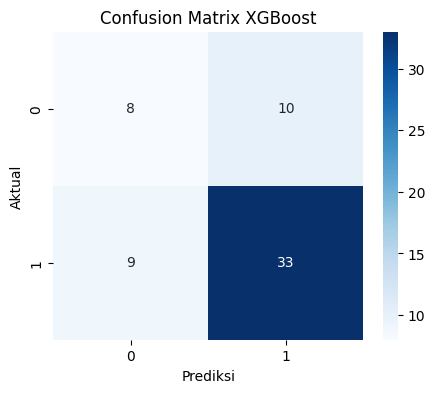

In [74]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix XGBoost")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.savefig("confusion_matrix_xgb.png", dpi=300, bbox_inches="tight")
plt.show()

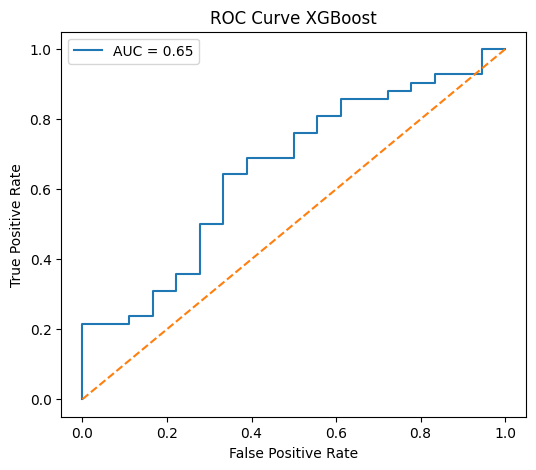

In [75]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(6,5))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"AUC = {roc_auc_xgb:.2f}"
)

plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("roc_curve_xgb.png", dpi=300, bbox_inches="tight")
plt.show()

In [67]:
hasil = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Support Vector Machine",
        "XGBoost"
    ],
    "Accuracy (%)": [
        accuracy_rf*100,
        accuracy_svm*100,
        accuracy_xgb*100
    ]
})

hasil

,Model,Accuracy (%)
0,Random Forest,73.333333
1,Support Vector Machine,70.000000
2,XGBoost,68.333333


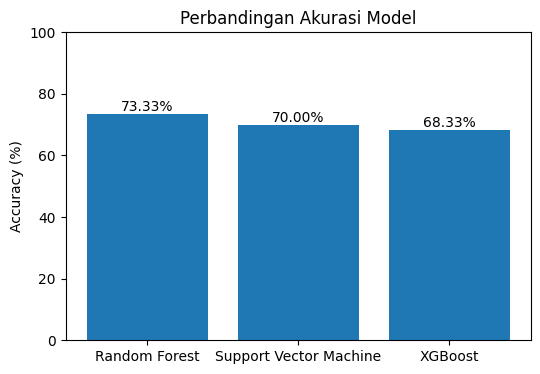

In [76]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    hasil["Model"],
    hasil["Accuracy (%)"]
)

plt.ylim(0,100)
plt.ylabel("Accuracy (%)")
plt.title("Perbandingan Akurasi Model")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        f"{bar.get_height():.2f}%",
        ha="center"
    )

plt.savefig("perbandingan_akurasi.png", dpi=300, bbox_inches="tight")
plt.show()

In [69]:
import os

os.listdir()

['.config',
 'roc_curve_svm.png',
 'roc_curve_rf.png',
 'correlation_heatmap.png',
 'random_forest_model.pkl',
 'confusion_matrix_rf.png',
 'confusion_matrix_svm.png',
 'sample_data']

| Model                        | Accuracy   |
| ---------------------------- | ---------- |
| Random Forest                | **73.33%** |
| Support Vector Machine (SVM) | **70.00%** |
| XGBoost                      | **68.33%** |


Berdasarkan hasil evaluasi terhadap tiga algoritma klasifikasi, Random Forest memperoleh nilai accuracy tertinggi sebesar 73,33%, diikuti oleh Support Vector Machine (SVM) sebesar 70,00%, dan XGBoost sebesar 68,33%. Hasil tersebut menunjukkan bahwa Random Forest memiliki kemampuan yang lebih baik dalam mengenali pola pada data penerima beasiswa dibandingkan dua algoritma lainnya.

